In [1]:
import tensorflow as tf

In [2]:
import matplotlib.pyplot as plt

In [3]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

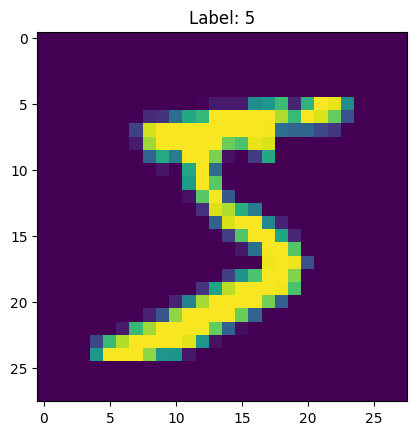

In [4]:
plt.figure()
plt.imshow(x_train[0])
plt.title(f"Label: {y_train[0]}")
plt.show()

In [5]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10),
])

2026-03-15 16:29:50.569878: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-03-15 16:29:50.569898: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-03-15 16:29:50.569904: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-03-15 16:29:50.569919: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-15 16:29:50.569929: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [6]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

predictions = tf.nn.softmax(model(x_train[:1])).numpy()
print(predictions)
print(y_train[:1])
print(loss_fn(y_train[:1], predictions).numpy())

[[0.04786286 0.10657443 0.05085871 0.15713023 0.07239966 0.085109
  0.08894309 0.10251746 0.02974139 0.25886324]]
[5]
2.3195226


In [7]:
model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

In [8]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5


2026-03-15 16:29:52.351406: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.8786 - loss: 0.4209
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8909 - loss: 0.3936
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8876 - loss: 0.4104
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8847 - loss: 0.4206
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8860 - loss: 0.4155


In [9]:
model.evaluate(x_test, y_test, verbose=2)

313/313 - 1s - 5ms/step - accuracy: 0.9131 - loss: 0.3260


[0.3259899914264679, 0.913100004196167]

In [10]:
probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])

In [11]:
probability_model(x_test[:5])

<tf.Tensor: shape=(5, 10), dtype=float32, numpy=
array([[2.5955622e-05, 3.6824257e-09, 6.4709352e-04, 6.6048844e-04,
        1.8549823e-05, 4.5523397e-05, 1.3378404e-07, 9.9813145e-01,
        1.5490463e-05, 4.5524459e-04],
       [8.3074754e-04, 4.4774072e-04, 7.5983536e-01, 2.3142584e-01,
        1.0091277e-06, 1.6546001e-03, 4.3013641e-03, 3.0429297e-07,
        1.4704168e-03, 3.2709228e-05],
       [7.8418932e-05, 5.4870224e-01, 2.2141235e-03, 1.7778093e-03,
        2.3113761e-02, 1.8007928e-03, 5.7884157e-03, 4.0586963e-01,
        7.1674894e-04, 9.9380249e-03],
       [3.6975950e-01, 4.3627952e-06, 4.0799024e-04, 4.5137796e-05,
        8.8673793e-03, 2.0392802e-04, 3.7473761e-03, 6.1123890e-01,
        1.2367084e-05, 5.7131890e-03],
       [2.0276404e-05, 1.9413382e-07, 6.5981076e-06, 1.6144473e-06,
        9.7862113e-01, 3.1177016e-05, 2.9078906e-04, 6.5233679e-03,
        1.5470969e-05, 1.4489428e-02]], dtype=float32)>

In [12]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [13]:
tf

<module 'tensorflow' from '/Users/dyoo/work/mlcc/.venv/lib/python3.12/site-packages/tensorflow/__init__.py'>